# **Barclays Transactional Data Analytics Project**

### Project Overview

This project focuses on performing an end-to-end financial transaction analysis using Barclays’ customer transactional dataset. The objective is to analyze customer behavior, transaction patterns, account performance, and financial risk indicators using Python-based data analytics techniques.

With the rise in digital transactions and diversified account usage, financial institutions must continuously monitor transaction trends, identify high-risk behavior, and segment customers based on financial activity. This project aims to simulate a real-world financial data analyst role by transforming raw transactional data into actionable business insights.

#Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9,5)

# Load, Inspect & Cleaning Data

Before starting any analysis, it's essential to load the dataset and understand its structure. Using df.info(), df.head(), and df.isnull().sum() allows us to quickly see the data types, the number of rows, and where missing values exist. This step ensures we know exactly what data we are working with and whether cleaning is required.

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Python_Project/Financial_Project/barclays_data.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [4]:
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,101.261250,53695.086727,72920.295572,0.472623,583.485000,122.306250
std,57.219779,30115.644050,34005.837334,0.232112,156.661453,66.564563
min,1.000000,-59669.075480,-30766.906970,-0.380361,305.000000,6.000000
25%,54.750000,33334.555715,49949.249088,0.315380,452.750000,64.000000
50%,100.000000,52765.641760,72252.815065,0.469889,591.500000,122.500000
75%,154.000000,74158.869990,97290.666368,0.623438,718.500000,175.000000
max,199.000000,166083.829600,184008.258800,1.257012,849.000000,239.000000


In [5]:
for i in df.columns:
    null_count = df[i].isnull().sum()
    if null_count > 0:
        print(f"Column '{i}' has {null_count} null values.")
    else:
        print(f"Column '{i}' has 0 null values.")

Column 'TransactionID' has 0 null values.
Column 'CustomerID' has 0 null values.
Column 'AccountID' has 0 null values.
Column 'AccountType' has 0 null values.
Column 'TransactionType' has 0 null values.
Column 'Product' has 0 null values.
Column 'Firm' has 0 null values.
Column 'Region' has 0 null values.
Column 'Manager' has 0 null values.
Column 'TransactionDate' has 0 null values.
Column 'TransactionAmount' has 0 null values.
Column 'AccountBalance' has 0 null values.
Column 'RiskScore' has 0 null values.
Column 'CreditRating' has 0 null values.
Column 'TenureMonths' has 0 null values.


# TASK 1: DATA CLEANING & FORMATTING

### 1. Remove/treat any special characters or non-numeric entries from financial fields

In [6]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


In [7]:
df["TransactionAmount"] = df["TransactionAmount"].replace('[₹$,]', '', regex=True)
df["AccountBalance"] = df["AccountBalance"].replace('[₹$,]', '', regex=True)

* Special characters such as **$** and commas were removed from **TransactionAmount** and **AccountBalance**.

* This ensures that financial columns contain only numeric values.

* Cleaning financial fields prevents type conversion errors and ensures accurate numerical computations.

* This step improves data integrity and prepares the dataset for aggregation and statistical analysis.

### 2. Convert currency amounts into numerical format.

In [8]:
df["TransactionAmount"] = df["TransactionAmount"].astype(float)
df["AccountBalance"] = df["AccountBalance"].astype(float)

* **TransactionAmount** and **AccountBalance** were successfully converted to **float** data type.

* This enables mathematical operations such as summation, averaging, volatility calculation, and hypothesis testing.

* Converting to numeric format ensures consistency and reliability in financial calculations.

### 3. Validate and format date columns.

In [9]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],dayfirst=True)

In [10]:
df["TransactionDate"].min()

Timestamp('2023-01-02 00:00:00')

In [11]:
df['TransactionDate'].max()

Timestamp('2024-06-22 00:00:00')

**Date Range Observed:**
- Minimum Date: 02 January 2023
- Maximum Date: 22 June 2024

* The TransactionDate column was converted to proper datetime format.

* The dataset spans approximately 18 months of financial transactions.

* This time range is sufficient for performing monthly and yearly trend analysis.

* Proper date formatting enables time-based grouping and dormancy detection.

### 4. Ensure account types and transaction categories are standardized.

In [12]:
df["AccountType"].value_counts()

,count
AccountType,
Loan,206
Credit,201
Current,198
Savings,195


In [13]:
df["TransactionType"].value_counts()

,count
TransactionType,
Withdrawal,210
Transfer,206
Payment,198
Deposit,186


In [14]:
df['Region'].value_counts()

,count
Region,
West,178
Central,161
South,160
East,156
North,145


- All categorical fields were standardized and validated.

- Account types are relatively evenly distributed across the portfolio.

- Withdrawal and Transfer transactions dominate, indicating higher outflow activity.

- Regional distribution is fairly balanced, with West region having the highest transaction activity.

- No unexpected or inconsistent category values were found, ensuring clean segmentation analysis in later stages.

# Task 2: Descriptive Transactional Analysis

### 1. Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [15]:
df['FlowType'] = np.where(
    df['TransactionType'] == 'Deposit',
    'Credit',
    'Debit'
)

df['FlowType'].value_counts()

,count
FlowType,
Debit,614
Credit,186


In [16]:
df['SignedAmount'] = np.where(
    df['FlowType'] == 'Credit',
    df['TransactionAmount'],
    -df['TransactionAmount']
)

In [17]:
df['YearMonth'] = df['TransactionDate'].dt.to_period('M').astype(str)
df['YearMonth'].head()

,YearMonth
0,2024-01
1,2023-12
2,2024-05
3,2023-12
4,2023-01


In [18]:
monthly_summary = df.groupby(['YearMonth','FlowType'])['TransactionAmount'].sum().round(2).unstack()

monthly_summary['NetVolume'] = (
    monthly_summary.get('Credit',0) -
    monthly_summary.get('Debit',0)
).round(2)

# Sort properly
monthly_summary.sort_index()

FlowType,Credit,Debit,NetVolume
YearMonth,,,
2023-01,569469.36,2216844.14,-1647374.78
2023-02,521830.58,2009549.48,-1487718.90
2023-03,342372.91,1159596.35,-817223.44
2023-04,146580.61,1551605.68,-1405025.07
2023-05,568697.32,2568690.51,-1999993.19
2023-06,488374.11,2415617.16,-1927243.05
2023-07,419545.01,1765712.45,-1346167.44
2023-08,547258.56,2359400.37,-1812141.81
2023-09,856750.21,1643811.96,-787061.75


**Flow Type Distribution:**

- Debit Transactions: 614

- Credit Transactions: 186

**Interpretation:**
- Debit transactions significantly outnumber credit transactions (approx. 3.3x higher).

- This indicates that customer accounts are predominantly experiencing outflows rather than inflows.

- The portfolio appears expenditure-heavy, which may impact liquidity and balance stability.

- Such a pattern may indicate high consumption behavior or frequent payment/transfer activity.

### 2. Plot trends in total credits vs. debits over time.

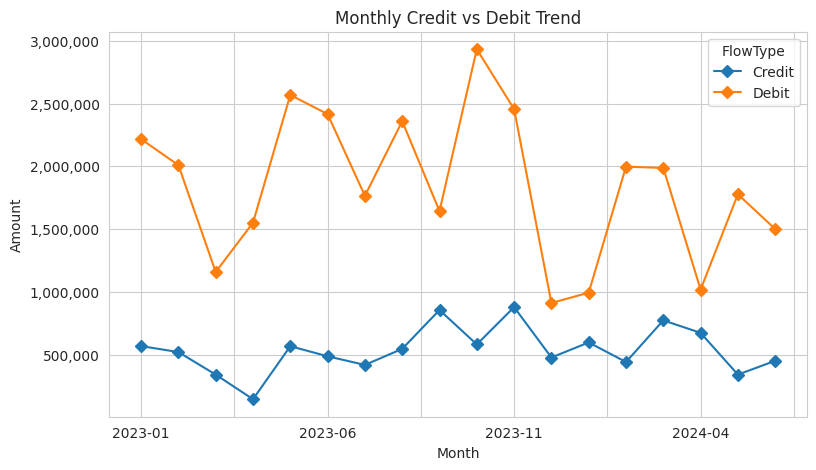

In [19]:
import matplotlib.ticker as ticker

ax = monthly_summary[['Credit','Debit']].plot(marker = "D")

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
#plt.xticks(rotation=45)
plt.show()

In [20]:
df.groupby('FlowType')['TransactionAmount'].sum().round(2)

,TransactionAmount
FlowType,
Credit,9686762.62
Debit,33269306.76


**Interpretation:**

- Debit amounts consistently exceed credit amounts throughout the observed period.

- Significant debit spikes are observed around October 2023 and mid-2024.

- Credit transactions remain relatively stable and lower in magnitude.

- This gap between credit and debit widens during certain months, indicating behavioral surges.

**Business Insight:**

- The portfolio demonstrates structurally higher outflows.

- Periodic debit spikes may represent EMI cycles, business payments, or seasonal spending.

- Risk monitoring should increase during high-debit months.

### 3. Identify top and bottom performing accounts based on net inflow.

In [21]:
account_performance = df.groupby('AccountID')['SignedAmount'].sum().reset_index()

account_performance = account_performance.sort_values(by='SignedAmount', ascending=False)

top_accounts = account_performance.head(10)
bottom_accounts = account_performance.tail(10)

top_accounts

,AccountID,SignedAmount
145,ACC76549,178514.787150
74,ACC39544,142078.535970
123,ACC64022,120503.785830
184,ACC95164,116682.838910
25,ACC21878,86417.091881
150,ACC77638,82866.550830
179,ACC92360,63072.095510
121,ACC62446,49845.569140
167,ACC86784,40509.319390
17,ACC18140,39462.592290


**Top Performing Accounts:**

- Highest Net Inflow: ACC76549 (178,514.79)

- Other top accounts maintain positive cumulative inflow.

**Interpretation:**

- These accounts maintain strong positive net cash flow.

- Likely stable or high-income customers.

- These accounts represent low-risk, high-value clients.

- Suitable candidates for premium financial products or cross-selling.

In [22]:
bottom_accounts

,AccountID,SignedAmount
113,ACC57597,-323685.75570
79,ACC42710,-324458.11313
7,ACC12334,-328726.21072
141,ACC74631,-335875.21189
87,ACC45968,-339222.52464
93,ACC49140,-377859.70172
20,ACC19178,-384900.83747
35,ACC25132,-448761.32916
88,ACC46655,-449599.01096
109,ACC54589,-597407.08601


**Bottom Performing Accounts:**

- Worst Performing Account: ACC54589 (-59,740.08)

- Several accounts show significant cumulative outflow.

**Interpretation:**

- These accounts consistently withdraw more than deposit.

- May indicate financial stress or high spending behavior.

- These accounts require monitoring for potential overdraft risk.

- Could benefit from balance alerts or financial advisory interventions.

### 4.  Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [23]:
df_c = df.sort_values(['AccountID','TransactionDate'])

df_c['PrevDate'] = df_c.groupby('AccountID')['TransactionDate'].shift(1)

df_c['GapDays'] = (df_c['TransactionDate'] - df_c['PrevDate']).dt.days

df_c['DormantFlag'] = np.where(df_c['GapDays'] >= 60, 1, 0)

dormant_accounts = df_c[df_c['DormantFlag'] == 1]['AccountID'].nunique()

dormant_accounts

166

In [24]:
df_c.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,SignedAmount,YearMonth,PrevDate,GapDays,DormantFlag
739,10,CUST2805,ACC10117,Savings,Transfer,Credit Card,Firm A,North,Manager 3,2023-06-01,...,94099.95036,0.744721,711,41,Debit,-40222.59774,2023-06,NaT,NaN,0
681,76,CUST6735,ACC10117,Loan,Payment,Credit Card,Firm D,North,Manager 1,2023-11-08,...,110937.57410,0.609497,687,236,Debit,-83158.65148,2023-11,2023-06-01,160.0,1
41,112,CUST8091,ACC10117,Loan,Deposit,Personal Loan,Firm A,West,Manager 2,2024-04-06,...,97023.17014,0.720880,400,148,Credit,54168.90233,2024-04,2023-11-08,150.0,1
265,72,CUST7002,ACC10117,Savings,Deposit,Mutual Fund,Firm B,North,Manager 2,2024-06-22,...,89254.12450,0.495491,586,93,Credit,60877.05837,2024-06,2024-04-06,77.0,1
201,103,CUST8772,ACC10996,Current,Deposit,Credit Card,Firm D,South,Manager 2,2023-01-17,...,67044.55433,0.656050,818,203,Credit,42376.42362,2023-01,NaT,NaN,0
585,72,CUST3041,ACC10996,Savings,Payment,Savings Account,Firm E,North,Manager 4,2023-10-16,...,66344.39469,0.670691,667,232,Debit,-77860.86889,2023-10,2023-01-17,272.0,1
164,34,CUST3810,ACC10996,Current,Deposit,Credit Card,Firm D,West,Manager 2,2023-10-19,...,72528.87137,0.343697,388,199,Credit,41107.21609,2023-10,2023-10-16,3.0,0
59,64,CUST9038,ACC10996,Savings,Withdrawal,Personal Loan,Firm C,West,Manager 1,2024-01-01,...,25464.12779,0.579622,797,217,Debit,-70136.96717,2024-01,2023-10-19,74.0,1
467,41,CUST3006,ACC10996,Current,Withdrawal,Home Loan,Firm A,North,Manager 2,2024-06-21,...,53528.81451,0.495873,665,104,Debit,-37989.87644,2024-06,2024-01-01,172.0,1
604,105,CUST6319,ACC11062,Credit,Withdrawal,Home Loan,Firm A,North,Manager 3,2023-11-08,...,49986.11210,0.477005,560,208,Debit,-34830.38980,2023-11,NaT,NaN,0


**Total Dormant Accounts Identified: 166**

**Interpretation:**

- A significant portion of accounts show inactivity periods of 60+ days.

- Dormancy may indicate:

  - Low engagement customers
  - Migrated customers
  - Secondary/backup accounts
- High dormancy can reduce active revenue potential.
- Bank may consider targeted re-engagement strategies.

# Task 3: Customer Profile Building

### 1. Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [25]:
txn_count = df.groupby('AccountID')['TransactionID'].count().reset_index()
txn_count.columns = ['AccountID','TransactionCount']

txn_count.head()

,AccountID,TransactionCount
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,4
4,ACC11285,3


In [26]:
txn_count.shape

(193, 2)

In [27]:
txn_count['TransactionCount'].describe()

,TransactionCount
count,193.000000
mean,4.145078
std,2.084089
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,11.000000


In [28]:
q1 = txn_count['TransactionCount'].quantile(0.33)
q2 = txn_count['TransactionCount'].quantile(0.66)

def activity_level(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

txn_count['ActivityLevel'] = txn_count['TransactionCount'].apply(activity_level)

txn_count['ActivityLevel'].value_counts()

,count
ActivityLevel,
Medium,84
Low,72
High,37


**Interpretation:**

- The majority of accounts fall under Medium activity level, indicating moderate engagement.

- Only 37 accounts fall under High activity, suggesting a smaller segment of highly engaged customers.

- The distribution is relatively balanced but skewed slightly toward moderate activity.

- High-activity accounts represent the most operationally active customers and require closer liquidity monitoring.

- Low-activity accounts may include dormant or secondary accounts.

**Business Insight:**

- The bank's portfolio is engagement-diverse.

- High-activity customers may drive transaction revenue.

- Low-activity customers present opportunities for re-engagement campaigns.

### 2. Segment customers by average balance and transaction volume.

In [29]:
profile_df = df.groupby('AccountID').agg({
    'TransactionAmount':'mean',
    'AccountBalance':'mean',
    'SignedAmount':'sum',
    'TransactionID':'count'
}).reset_index()

profile_df.columns = [
    'AccountID',
    'AvgTransactionAmount',
    'AvgBalance',
    'NetInflow',
    'TransactionCount'
]

profile_df.head()

,AccountID,AvgTransactionAmount,AvgBalance,NetInflow,TransactionCount
0,ACC10117,59606.802480,97828.704775,-8335.28852,4
1,ACC10996,53894.270442,56982.152538,-102504.07279,5
2,ACC11062,55297.391990,65947.316965,-110594.78398,2
3,ACC11188,56379.364735,81169.114065,-183846.36624,4
4,ACC11285,78706.515337,62574.613950,-236119.54601,3


**Interpretation:**

- Average balances vary significantly across accounts.

- Several accounts show negative net inflow despite moderate transaction counts.

- Some accounts maintain high average balances even with low transaction frequency, indicating wealth retention behavior.

- Transaction frequency alone does not fully determine financial strength.

**Business Insight:**

- Customers with high average balances but low frequency may be long-term wealth holders.

- Customers with high transaction count but low balance may be high-spending or liquidity-constrained.

### 3. Create profiles for:
* High-net inflow accounts
* High-frequency low-balance accounts
* Accounts with negative or near-zero balances



In [30]:
high_inflow = profile_df.sort_values(by='NetInflow', ascending=False).head(10)

high_inflow

,AccountID,AvgTransactionAmount,AvgBalance,NetInflow,TransactionCount
145,ACC76549,51381.556102,53827.231368,178514.787150,4
74,ACC39544,71039.267985,95920.874435,142078.535970,2
123,ACC64022,66109.327510,79921.876670,120503.785830,5
184,ACC95164,59714.052222,101053.902210,116682.838910,5
25,ACC21878,47419.155472,73072.795134,86417.091881,7
150,ACC77638,41535.122602,61707.391677,82866.550830,4
179,ACC92360,57574.997759,86519.525884,63072.095510,7
121,ACC62446,49845.569140,16878.131640,49845.569140,1
167,ACC86784,40509.319390,76620.602830,40509.319390,1
17,ACC18140,39638.684305,111048.708525,39462.592290,2


**Top account example:**

- ACC76549 → Net Inflow: 178,514.79

**Interpretation:**

- These accounts consistently deposit more than withdraw.

- They demonstrate strong positive cash flow behavior.

- Likely low-risk and financially stable customers.

- Ideal candidates for premium banking products or investment offerings.

In [31]:
high_freq_threshold = profile_df['TransactionCount'].quantile(0.75)
low_balance_threshold = profile_df['AvgBalance'].quantile(0.25)

high_freq_low_balance = profile_df[
    (profile_df['TransactionCount'] > high_freq_threshold) &
    (profile_df['AvgBalance'] < low_balance_threshold)
]

high_freq_low_balance

,AccountID,AvgTransactionAmount,AvgBalance,NetInflow,TransactionCount
52,ACC30146,51741.561245,49391.925607,-111078.18127,6
88,ACC46655,56199.876370,57869.987550,-449599.01096,8
93,ACC49140,62976.616953,50181.177676,-377859.70172,6
97,ACC49422,51358.503041,62362.266610,-304212.46853,11
109,ACC54589,72010.359559,54155.282135,-597407.08601,10
128,ACC66086,55661.245948,46633.161371,-117988.00799,6
151,ACC77773,68026.950383,48124.053400,-146180.17482,7
180,ACC92558,71676.566917,50319.279200,-278353.15803,9


**Accounts identified show:**

- High transaction counts (above 75th percentile)
- Low average balances (below 25th percentile)

**Interpretation:**
- These accounts transact frequently but maintain low balances.

- This may indicate high expenditure behavior or liquidity pressure.

- Such accounts carry higher financial risk exposure.

- These customers may benefit from financial advisory or spending alerts.

**Risk Perspective:**

- High activity + low balance = potential overdraft vulnerability.

- This segment requires proactive monitoring.

In [32]:
low_balance_cutoff = profile_df['AvgBalance'].quantile(0.10)

negative_accounts = profile_df[
    profile_df['AvgBalance'] <= low_balance_cutoff
]

negative_accounts

,AccountID,AvgTransactionAmount,AvgBalance,NetInflow,TransactionCount
33,ACC24880,56798.805120,32516.729161,-38738.135240,4
52,ACC30146,51741.561245,49391.925607,-111078.181270,6
54,ACC30852,67619.211083,27044.090537,-75627.099670,3
78,ACC42467,17476.407921,47684.159638,-61362.014590,4
82,ACC43771,117259.116800,45725.221140,-117259.116800,1
91,ACC48303,38769.272470,46465.831480,-38769.272470,1
93,ACC49140,62976.616953,50181.177676,-377859.701720,6
96,ACC49395,56368.720523,50610.804330,-26725.809270,3
99,ACC50439,43013.369558,50199.215838,-167059.035390,5
121,ACC62446,49845.569140,16878.131640,49845.569140,1


***Accounts identified based on lowest 10% average balances.***

**Interpretation:**

- These accounts maintain consistently low liquidity.
- Many show negative net inflow.
- These customers may be financially stressed or high spenders.
- Increased probability of overdrafts and default behavior.

**Risk Insight:**
- This segment is the most financially vulnerable.
- Ideal for risk scoring enhancement.

# Task 4: Financial Risk Identification

### 1. Track accounts with frequent large withdrawals or overdrafts.

In [33]:
df.head(5)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,SignedAmount,YearMonth
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,2024-01-08,20664.409820,88483.42208,0.483333,522,29,Credit,20664.409820,2024-01
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,2023-12-17,94924.359120,56670.15864,0.788989,686,130,Credit,94924.359120,2023-12
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,2024-05-22,-7871.160407,84968.05587,0.547782,618,157,Debit,7871.160407,2024-05
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,2023-12-24,24979.808160,115196.96420,0.125587,803,155,Debit,-24979.808160,2023-12
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,2023-01-15,72890.748550,111602.76610,1.048787,657,68,Debit,-72890.748550,2023-01


In [34]:
debit_df = df[df['FlowType'] == 'Debit']

large_threshold = debit_df['TransactionAmount'].quantile(0.95)

print(large_threshold.round(2))

106634.97


In [35]:
df['LargeWithdrawalFlag'] = np.where(
    (df['FlowType'] == 'Debit') &
    (df['TransactionAmount'] >= large_threshold),
    1, 0
)

print(df['LargeWithdrawalFlag'].sum())

31


In [36]:
df[df["LargeWithdrawalFlag"]==1].head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,SignedAmount,YearMonth,LargeWithdrawalFlag
9,150,CUST8091,ACC23736,Credit,Transfer,Savings Account,Firm A,North,Manager 1,2023-11-25,107378.5572,33243.17354,0.111676,814,181,Debit,-107378.5572,2023-11,1
121,180,CUST2842,ACC49180,Current,Withdrawal,Home Loan,Firm C,North,Manager 3,2024-04-01,109356.8390,45153.93637,0.560205,388,162,Debit,-109356.8390,2024-04,1
122,116,CUST9216,ACC71388,Savings,Withdrawal,Home Loan,Firm A,South,Manager 4,2024-05-27,122857.8311,71249.53038,0.584713,436,177,Debit,-122857.8311,2024-05,1
126,55,CUST9420,ACC77773,Current,Transfer,Mutual Fund,Firm D,Central,Manager 3,2023-08-23,109616.6373,15721.03730,0.506834,671,71,Debit,-109616.6373,2023-08,1
129,47,CUST8318,ACC13357,Loan,Transfer,Savings Account,Firm B,East,Manager 2,2023-04-26,107480.8425,84277.08547,0.202534,434,63,Debit,-107480.8425,2023-04,1
187,122,CUST6350,ACC32890,Credit,Transfer,Credit Card,Firm B,West,Manager 2,2023-04-30,119904.5257,97507.84045,0.876224,693,149,Debit,-119904.5257,2023-04,1
192,161,CUST9564,ACC54589,Credit,Transfer,Home Loan,Firm D,Central,Manager 2,2024-02-05,108673.8390,108556.52040,1.082312,823,178,Debit,-108673.8390,2024-02,1
233,39,CUST9079,ACC25132,Current,Payment,Mutual Fund,Firm A,Central,Manager 2,2023-09-28,109032.1354,104972.20120,0.368390,308,210,Debit,-109032.1354,2023-09,1
242,17,CUST8390,ACC97411,Current,Transfer,Credit Card,Firm A,Central,Manager 3,2023-09-11,108372.6035,103617.80280,1.049439,363,15,Debit,-108372.6035,2023-09,1
251,157,CUST2871,ACC43771,Credit,Withdrawal,Mutual Fund,Firm D,East,Manager 4,2023-05-11,117259.1168,45725.22114,0.596077,380,181,Debit,-117259.1168,2023-05,1


### 2. Calculate balance volatility using standard deviation or coefficient of variation.

In [37]:
balance_volatility = df.groupby('AccountID')['AccountBalance'].std().reset_index()

balance_volatility.columns = ['AccountID','BalanceStdDev']

balance_volatility.head()

,AccountID,BalanceStdDev
0,ACC10117,9308.031969
1,ACC10996,18946.737199
2,ACC11062,22572.552392
3,ACC11188,20160.417506
4,ACC11285,70126.826097


In [38]:
volatility_threshold = balance_volatility['BalanceStdDev'].quantile(0.90)

high_volatility_accounts = balance_volatility[
    balance_volatility['BalanceStdDev'] >= volatility_threshold
]

print(high_volatility_accounts["AccountID"].count())

18


### 3. Use IQR or z-score methods to detect anomalies.

In [39]:
Q1 = df["TransactionAmount"].quantile(0.25).round(2)
Q3 = df["TransactionAmount"].quantile(0.75).round(2)
IQR = Q3 - Q1

print(f"Q1 value is:{Q1}")
print(f"Q3 value is:{Q3}")
print(f"IQR value is:{IQR}")

Q1 value is:33334.56
Q3 value is:74158.87
IQR value is:40824.31


In [40]:
lower_level = Q1 - 1.5 * IQR
upper_level = Q3 + 1.5 * IQR
print("Lower lever is:", lower_level.round(2))
print("Upper lever is:", upper_level.round(2))

Lower lever is: -27901.9
Upper lever is: 135395.34


In [41]:
anomaly = df[(df["TransactionAmount"]< lower_level) | (df["TransactionAmount"] > upper_level )]
anomaly

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,SignedAmount,YearMonth,LargeWithdrawalFlag
6,14,CUST5558,ACC82947,Credit,Payment,Credit Card,Firm A,East,Manager 2,2023-09-26,-43698.75917,124963.76370,0.460877,433,110,Debit,43698.75917,2023-09,0
48,6,CUST2427,ACC80131,Current,Deposit,Mutual Fund,Firm C,South,Manager 1,2023-11-19,141600.74000,58800.35045,0.130982,313,168,Credit,141600.74000,2023-11,0
200,169,CUST2188,ACC40939,Loan,Payment,Mutual Fund,Firm C,Central,Manager 2,2024-03-12,-29124.62485,70433.48821,0.695776,594,141,Debit,29124.62485,2024-03,0
312,167,CUST9843,ACC21264,Current,Transfer,Home Loan,Firm C,East,Manager 2,2023-06-20,149404.33020,71076.77650,0.371491,769,61,Debit,-149404.33020,2023-06,1
589,190,CUST1738,ACC90887,Savings,Withdrawal,Savings Account,Firm C,East,Manager 2,2024-01-20,-59669.07548,56004.32009,0.226499,502,172,Debit,59669.07548,2024-01,0
622,12,CUST1121,ACC43309,Credit,Transfer,Savings Account,Firm B,South,Manager 1,2023-10-16,166083.82960,69875.76042,0.708081,372,230,Debit,-166083.82960,2023-10,1
710,117,CUST3041,ACC95164,Credit,Deposit,Credit Card,Firm A,West,Manager 3,2024-04-06,142081.62900,60296.30589,0.368576,560,104,Credit,142081.62900,2024-04,0


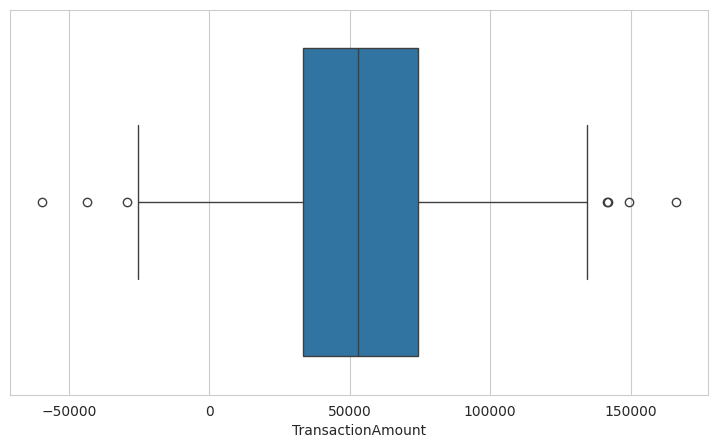

In [42]:
sns.boxplot(x=df["TransactionAmount"])
plt.show()

### 4. Highlight customers with irregular or suspicious transaction behavior.

In [43]:
risk_summary = df.groupby('AccountID').agg({
    'LargeWithdrawalFlag':'sum',
}).reset_index()

risk_summary = risk_summary.merge(balance_volatility, on='AccountID', how='left')

risk_summary.head()

,AccountID,LargeWithdrawalFlag,BalanceStdDev
0,ACC10117,0,9308.031969
1,ACC10996,0,18946.737199
2,ACC11062,0,22572.552392
3,ACC11188,0,20160.417506
4,ACC11285,0,70126.826097


In [44]:
risk_summary = risk_summary.sort_values(
    by=['LargeWithdrawalFlag','BalanceStdDev'],
    ascending=False
)

risk_summary.head(10)

,AccountID,LargeWithdrawalFlag,BalanceStdDev
149,ACC77592,1,70420.099530
85,ACC45907,1,57808.220119
14,ACC16664,1,52068.392699
141,ACC74631,1,50452.054088
38,ACC26940,1,46040.779617
84,ACC45521,1,45454.361140
22,ACC21264,1,45378.210441
94,ACC49180,1,44373.535740
101,ACC51009,1,43448.176898
59,ACC32890,1,42440.780859


# Task 5: Visualisation

### Conduct extensive exploratory data analysis with attractive visualizations for your findings

1. Monthly Credit vs Debit Trend

<Figure size 900x500 with 0 Axes>

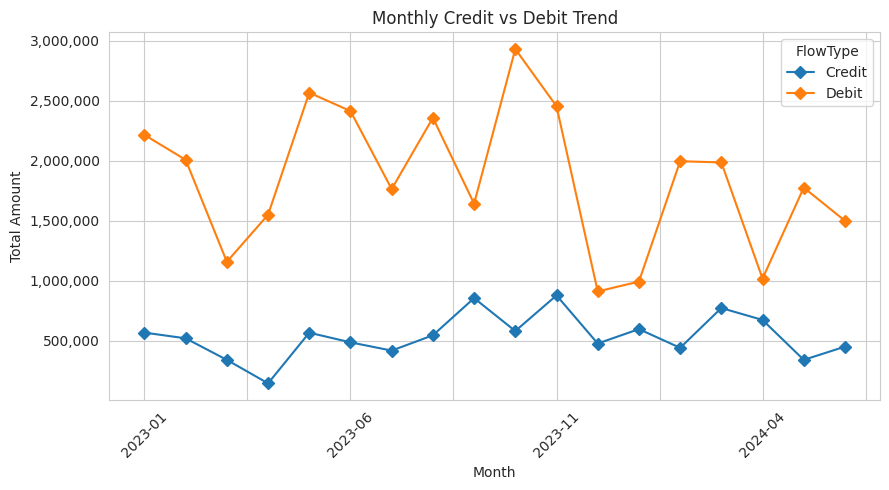

In [45]:
plt.figure()
ax = monthly_summary[['Credit','Debit']].plot(marker = "D")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Net Transaction Volume Over Time

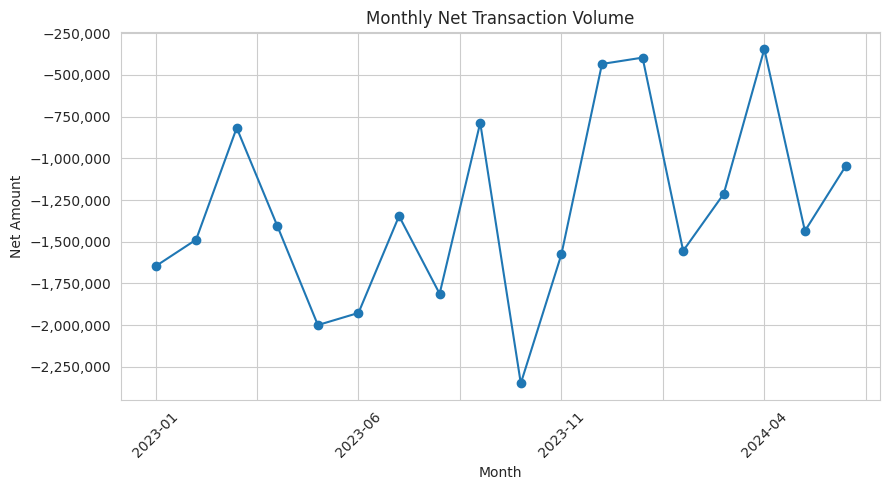

In [46]:
plt.figure()
ax = monthly_summary['NetVolume'].plot(marker = "o")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Monthly Net Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Net Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Transaction Type Distribution

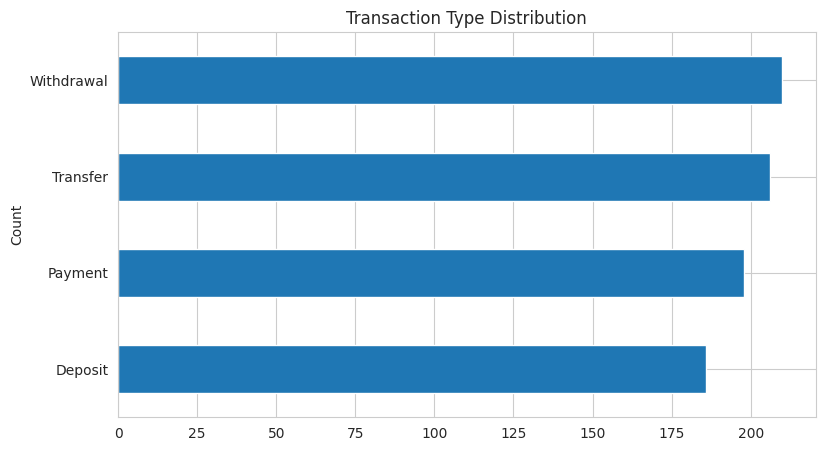

In [47]:
plt.figure()
df['TransactionType'].value_counts().sort_values().plot(kind='barh')
plt.title("Transaction Type Distribution")
plt.ylabel("Count")
plt.show()

4. Account Activity Level Distribution

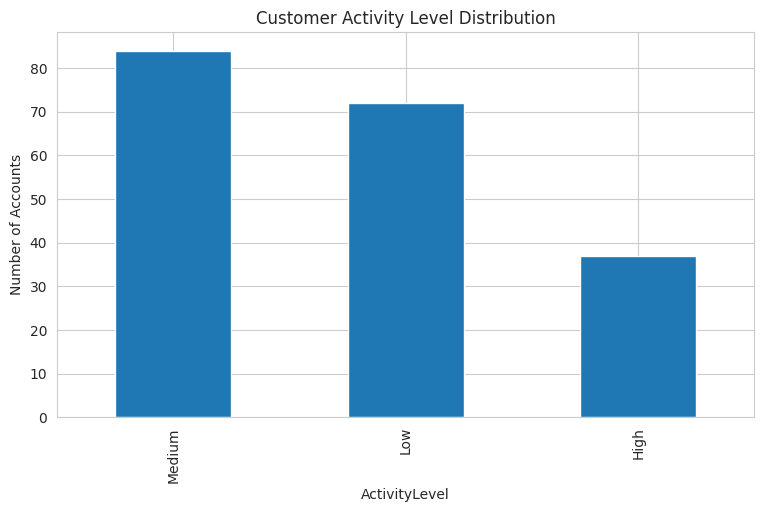

In [48]:
plt.figure()
txn_count['ActivityLevel'].value_counts().plot(kind='bar')
plt.title("Customer Activity Level Distribution")
plt.ylabel("Number of Accounts")
plt.show()

5. Balance Volatility Distribution

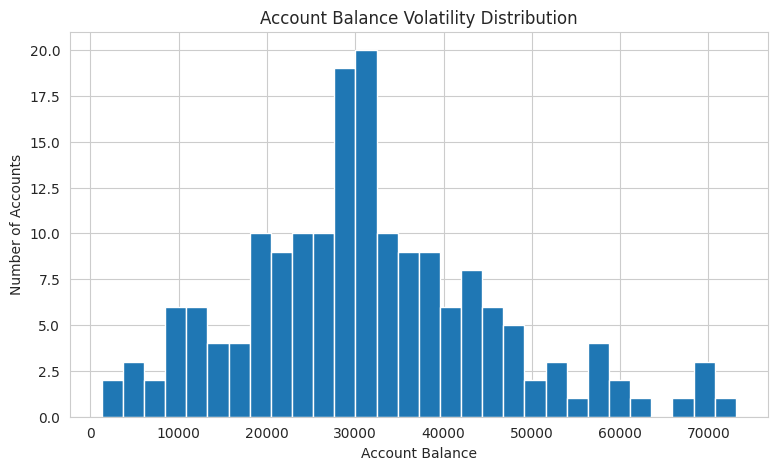

In [49]:
plt.figure()
plt.hist(balance_volatility['BalanceStdDev'], bins=30)
plt.title("Account Balance Volatility Distribution")
plt.xlabel("Account Balance")
plt.ylabel("Number of Accounts")
plt.show()

6. Scatter Plot – Frequency vs Average Balance

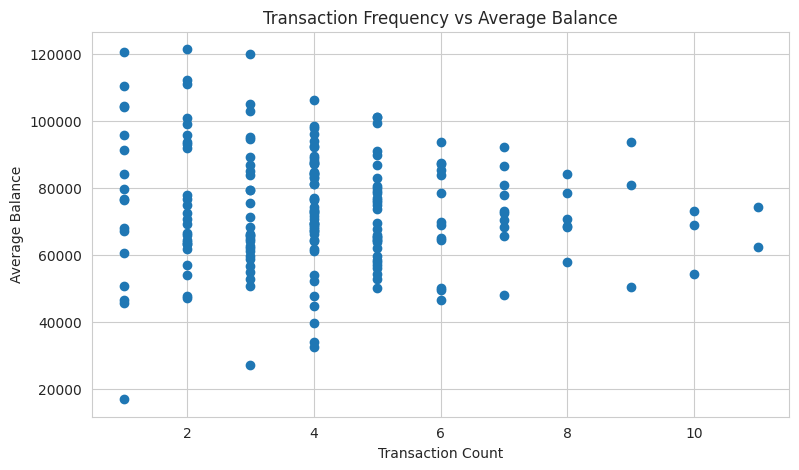

In [50]:
plt.figure()
plt.scatter(profile_df['TransactionCount'], profile_df['AvgBalance'])
plt.title("Transaction Frequency vs Average Balance")
plt.xlabel("Transaction Count")
plt.ylabel("Average Balance")
plt.show()

# Task 6: Hypothesis Testing

1. Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.


In [51]:
profile_df.head()

,AccountID,AvgTransactionAmount,AvgBalance,NetInflow,TransactionCount
0,ACC10117,59606.802480,97828.704775,-8335.28852,4
1,ACC10996,53894.270442,56982.152538,-102504.07279,5
2,ACC11062,55297.391990,65947.316965,-110594.78398,2
3,ACC11188,56379.364735,81169.114065,-183846.36624,4
4,ACC11285,78706.515337,62574.613950,-236119.54601,3


Volume segmentation defined using median transaction count.

In [52]:

median_txn = profile_df['TransactionCount'].median()

profile_df['VolumeSegment'] = profile_df['TransactionCount'].apply(
    lambda x: 'High Volume' if x >= median_txn else 'Low Volume'
)

profile_df['VolumeSegment'].value_counts()

,count
VolumeSegment,
High Volume,121
Low Volume,72


**Interpretation:**

- The majority of accounts fall under High Volume based on median split.
- This ensures balanced statistical comparison between groups.
- Median-based segmentation avoids extreme value bias.

2. Conduct hypothesis testing based on segmentation

In [53]:
from scipy.stats import ttest_ind

In [54]:
high_volume_balances = profile_df[
    profile_df['VolumeSegment'] == 'High Volume'
]['AvgBalance']

low_volume_balances = profile_df[
    profile_df['VolumeSegment'] == 'Low Volume'
]['AvgBalance']

**Null Hypothesis (H0):**

There is no significant difference in average balance between high-volume and low-volume accounts.

---

**Alternative Hypothesis (H1):**

High-volume accounts have significantly different average balances than low-volume accounts.

In [55]:
t_stat, p_value = ttest_ind(high_volume_balances, low_volume_balances, equal_var=False)

print(f"T-statistic: {t_stat.round(2)}, P-value: {p_value.round(2)}")

T-statistic: -0.86, P-value: 0.39


**Interpret Result**

If:
- p_value < 0.05 → Reject Null Hypothesis
- p_value > 0.05 → Fail to Reject Null Hypothesis

In [56]:
# Statistical Decision
if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference exists.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference.")

Fail to Reject Null Hypothesis: No significant difference.


In [57]:
profile_df.groupby('VolumeSegment')['AvgBalance'].mean()

,AvgBalance
VolumeSegment,
High Volume,72848.988369
Low Volume,75328.381464


**Interpretation:**

- There is no statistically significant difference in average balances between high-volume and low-volume accounts.
- Transaction frequency does not significantly impact the average balance maintained by customers.
- Although low-volume accounts show slightly higher average balances numerically, the difference is not statistically meaningful.
- Customer financial strength appears independent of transaction frequency.

**Business Insight**
- High transaction activity does not necessarily indicate higher liquidity.
- Some low-frequency accounts maintain higher balances, suggesting wealth retention behavior.
- Risk assessment should not rely solely on transaction volume.
- Balance behavior and volatility metrics should be incorporated into risk modeling.

**Hypothesis Conclusion**

The statistical test confirms that transaction volume alone is not a strong predictor of average balance.
Financial behavior segmentation must include additional parameters such as volatility, net inflow, and risk indicators.